In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Check current location
cwd = os.getcwd()
data_dir = "../data/processed/" if "notebooks" in cwd else "code/data/processed/"
print(f"Data directory: {data_dir}")

Data directory: ../data/processed/


In [2]:
bid_file = os.path.join(data_dir, "eurusd_dukascopy_bid_202601.parquet")
ask_file = os.path.join(data_dir, "eurusd_dukascopy_ask_202601.parquet")

df_bid = pd.read_parquet(bid_file)[['datetime', 'price']].rename(columns={'price': 'bid'})
df_ask = pd.read_parquet(ask_file)[['datetime', 'price']].rename(columns={'price': 'ask'})

print(f"Loaded {len(df_bid):,} Bid ticks and {len(df_ask):,} Ask ticks.")

Loaded 1,506,261 Bid ticks and 1,506,261 Ask ticks.


In [3]:
df_bid = df_bid.sort_values('datetime')
df_ask = df_ask.sort_values('datetime')

# Sync them (match closest bid to every ask)
df = pd.merge_asof(df_ask, df_bid, on='datetime', direction='nearest')
df['mid'] = (df['bid'] + df['ask']) / 2
df.set_index('datetime', inplace=True)
print(f"Data Merged. Total: {len(df):,}")

Data Merged. Total: 1,506,261


In [4]:
df_clipped = df.between_time('08:00', '17:00')
print(f"Clipped: {len(df_clipped):,} ticks.")

Clipped: 821,883 ticks.


In [5]:
K_TICKS = 50
df_preavg = df_clipped['mid'].rolling(window=K_TICKS).mean()
df_final = df_preavg.iloc[::K_TICKS].dropna().to_frame(name='mid_price')
print(f"Pre-averaged. Final size: {len(df_final):,}")

Pre-averaged. Final size: 16,437


In [6]:
df_final['returns'] = np.log(df_final['mid_price']).diff()
df_final = df_final.dropna()
print("Returns calculated.")

Returns calculated.


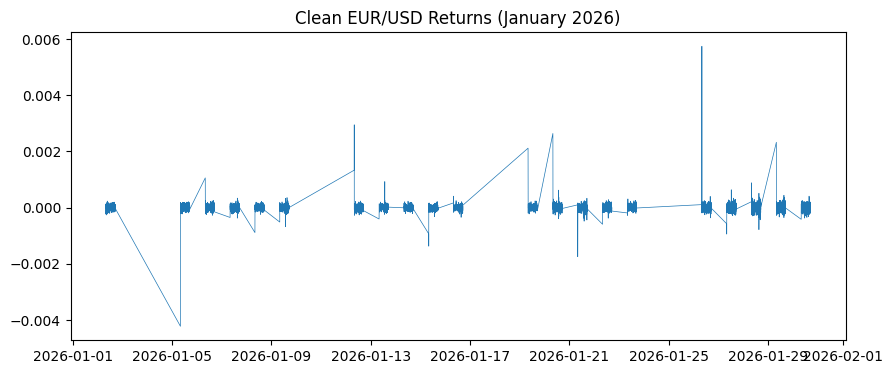

In [7]:
plt.figure(figsize=(10, 4))
plt.plot(df_final['returns'], lw=0.5)
plt.title("Clean EUR/USD Returns (January 2026)")
plt.show()

In [8]:
out_path = os.path.join(data_dir, "eurusd_clean_returns_jan2026.parquet")
df_final.to_parquet(out_path)
print(f"SUCCESS: Saved to {out_path}")

SUCCESS: Saved to ../data/processed/eurusd_clean_returns_jan2026.parquet


In [9]:
print("=" * 70)
print("PRE-PROCESSING COMPLETE")
print("-" * 70)
print(f"Final observations: {len(df_final):,}")
print(f"Sample Std: {df_final['returns'].std():.8f}")
print("=" * 70)

PRE-PROCESSING COMPLETE
----------------------------------------------------------------------
Final observations: 16,436
Sample Std: 0.00011562
